In [1]:
from multiRobotPathPlanner import MultiRobotPathPlanner
import numpy as np 
import matplotlib.pyplot as plt


H = 10
W = 10
grid = (H, W)
nep = True # not equal portions is true 
obstacle_positions = [5, 6, 7]
n = 3 # number of robots 
initial_positions = [0, 3, 9]
# portions = [0.2, 0.3, 0.5]
portions = [1/n for i in range(n)]
vis = True

enemy_pos_list = [(5,5), (6,6), (7,7)]
importance_grid = np.zeros(grid)
threat_grid = np.zeros(grid)
# background noise 
reward_grid = np.ones(grid)
searched_grid = np.zeros(grid)

for enemy_pos in enemy_pos_list: 
	threat_grid[enemy_pos[0]][enemy_pos[1]] = 0.5

# triples of (x,y,radius) 
prior_positions = [(5,6,1)]
prior_weight = 1
for prior_pos in prior_positions: 
	x = prior_pos[0]
	y = prior_pos[1]
	sigma = prior_pos[2]

	# Update neighboring cells with Gaussian centered at current position
	for i in range(H): 
		for j in range(W): 
			dist_squared = (i-x)**2 + (j-y)**2 + 1
			reward_grid[i][j] += prior_weight / (sigma * dist_squared)
	# print(reward_grid[x][y])

# print(reward_grid)
# construct the importance grid 
importance_grid = (1 - searched_grid) * reward_grid + threat_grid
print(importance_grid)

# plt.imshow(importance_grid, cmap='hot', interpolation='nearest')
# plt.colorbar()
# plt.show()

value_grid = []
for i in range(H):
	for j in range(W):
		value_grid.append((i*W + j , importance_grid[i][j]))

planner = MultiRobotPathPlanner(grid[0], grid[1], nep, initial_positions, portions, obstacle_positions, vis, value_grid, MaxIter=10000)

def coord_to_index(x, y):
    return x * W + y


pygame 2.6.0 (SDL 2.28.4, Python 3.12.4)
Hello from the pygame community. https://www.pygame.org/contribute.html
[[1.01612903 1.01960784 1.02380952 1.02857143 1.03333333 1.03703704
  1.03846154 1.03703704 1.03333333 1.02857143]
 [1.01886792 1.02380952 1.03030303 1.03846154 1.04761905 1.05555556
  1.05882353 1.05555556 1.04761905 1.03846154]
 [1.02173913 1.02857143 1.03846154 1.05263158 1.07142857 1.09090909
  1.1        1.09090909 1.07142857 1.05263158]
 [1.02439024 1.03333333 1.04761905 1.07142857 1.11111111 1.16666667
  1.2        1.16666667 1.11111111 1.07142857]
 [1.02631579 1.03703704 1.05555556 1.09090909 1.16666667 1.33333333
  1.5        1.33333333 1.16666667 1.09090909]
 [1.02702703 1.03846154 1.05882353 1.1        1.2        2.
  2.         1.5        1.2        1.1       ]
 [1.02631579 1.03703704 1.05555556 1.09090909 1.16666667 1.33333333
  2.         1.33333333 1.16666667 1.09090909]
 [1.02439024 1.03333333 1.04761905 1.07142857 1.11111111 1.16666667
  1.2        1.6666666

In [3]:
planner.best_case.paths

[[(0, 0, 1, 0),
  (1, 0, 2, 0),
  (2, 0, 3, 0),
  (3, 0, 4, 0),
  (4, 0, 5, 0),
  (5, 0, 6, 0),
  (6, 0, 7, 0),
  (7, 0, 8, 0),
  (8, 0, 9, 0),
  (9, 0, 10, 0),
  (10, 0, 11, 0),
  (11, 0, 12, 0),
  (12, 0, 13, 0),
  (13, 0, 14, 0),
  (14, 0, 15, 0),
  (15, 0, 16, 0),
  (16, 0, 17, 0),
  (17, 0, 18, 0),
  (18, 0, 19, 0),
  (19, 0, 19, 1),
  (19, 1, 19, 2),
  (19, 2, 19, 3),
  (19, 3, 19, 4),
  (19, 4, 19, 5),
  (19, 5, 19, 6),
  (19, 6, 19, 7),
  (19, 7, 19, 8),
  (19, 8, 19, 9),
  (19, 9, 19, 10),
  (19, 10, 19, 11),
  (19, 11, 18, 11),
  (18, 11, 18, 10),
  (18, 10, 18, 9),
  (18, 9, 17, 9),
  (17, 9, 16, 9),
  (16, 9, 16, 8),
  (16, 8, 17, 8),
  (17, 8, 18, 8),
  (18, 8, 18, 7),
  (18, 7, 17, 7),
  (17, 7, 16, 7),
  (16, 7, 15, 7),
  (15, 7, 14, 7),
  (14, 7, 13, 7),
  (13, 7, 12, 7),
  (12, 7, 12, 6),
  (12, 6, 13, 6),
  (13, 6, 14, 6),
  (14, 6, 15, 6),
  (15, 6, 16, 6),
  (16, 6, 17, 6),
  (17, 6, 18, 6),
  (18, 6, 18, 5),
  (18, 5, 17, 5),
  (17, 5, 16, 5),
  (16, 5, 15, 5),
  (

In [9]:
planner.best_case.paths[0]

[(0, 0, 1, 0),
 (1, 0, 2, 0),
 (2, 0, 3, 0),
 (3, 0, 4, 0),
 (4, 0, 5, 0),
 (5, 0, 6, 0),
 (6, 0, 7, 0),
 (7, 0, 8, 0),
 (8, 0, 9, 0),
 (9, 0, 10, 0),
 (10, 0, 11, 0),
 (11, 0, 12, 0),
 (12, 0, 13, 0),
 (13, 0, 14, 0),
 (14, 0, 15, 0),
 (15, 0, 16, 0),
 (16, 0, 17, 0),
 (17, 0, 18, 0),
 (18, 0, 19, 0),
 (19, 0, 19, 1),
 (19, 1, 19, 2),
 (19, 2, 19, 3),
 (19, 3, 19, 4),
 (19, 4, 19, 5),
 (19, 5, 19, 6),
 (19, 6, 19, 7),
 (19, 7, 19, 8),
 (19, 8, 19, 9),
 (19, 9, 19, 10),
 (19, 10, 19, 11),
 (19, 11, 18, 11),
 (18, 11, 18, 10),
 (18, 10, 18, 9),
 (18, 9, 17, 9),
 (17, 9, 16, 9),
 (16, 9, 16, 8),
 (16, 8, 17, 8),
 (17, 8, 18, 8),
 (18, 8, 18, 7),
 (18, 7, 17, 7),
 (17, 7, 16, 7),
 (16, 7, 15, 7),
 (15, 7, 14, 7),
 (14, 7, 13, 7),
 (13, 7, 12, 7),
 (12, 7, 12, 6),
 (12, 6, 13, 6),
 (13, 6, 14, 6),
 (14, 6, 15, 6),
 (15, 6, 16, 6),
 (16, 6, 17, 6),
 (17, 6, 18, 6),
 (18, 6, 18, 5),
 (18, 5, 17, 5),
 (17, 5, 16, 5),
 (16, 5, 15, 5),
 (15, 5, 14, 5),
 (14, 5, 13, 5),
 (13, 5, 12, 5),
 (12, 5,

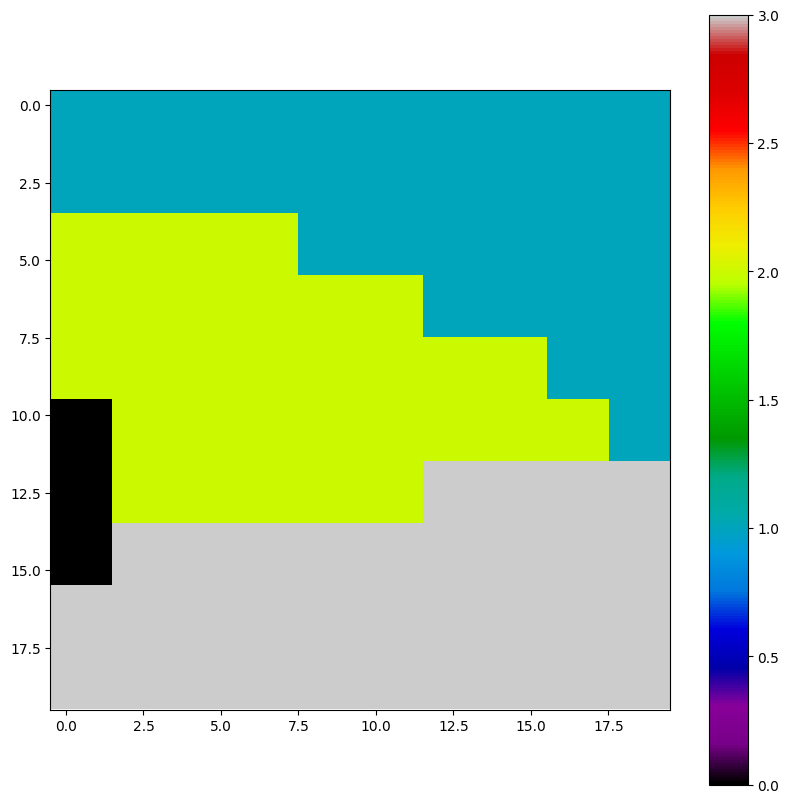

In [8]:

paths = planner.best_case.paths
for i in range(n):
    sum = 0
    for j in paths[i]:
        x = j[0]//2 
        y = j[1]//2
        sum += importance_grid[x][y]

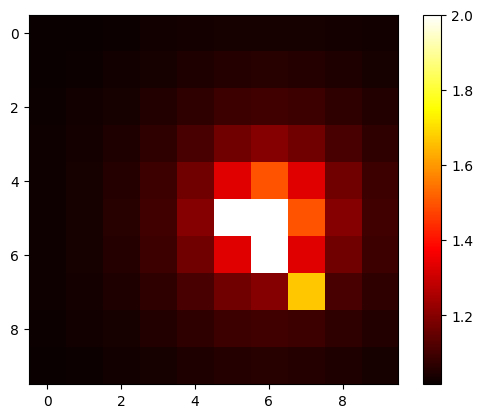

In [4]:
plt.imshow(importance_grid, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.show()

In [7]:
paths = planner.best_case.paths
print(len(paths))

3


[0, 2, 3, 9, 10, 12, 19, 20, 29, 30]


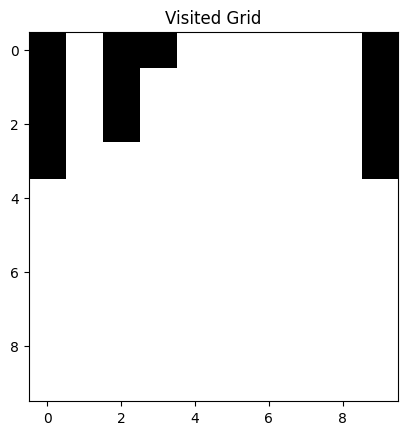

In [14]:
## suppose drone x is shot down at time step t
t = 8
d = 0

visited = np.zeros(grid)
last_pos = []
for i in range(n):
	for tt in range(t): 
		x = paths[i][tt][0] // 2
		y = paths[i][tt][1] // 2
		visited[x][y] = 1
	if i != d: 
		x_prime = paths[i][tt][2] // 2
		y_prime = paths[i][tt][3] // 2
		last_pos.append((x, y))

obstacles_prime = []
for x in range(H):
	for y in range(W): 
		if visited[x][y] == 1: 
			if (x,y) not in last_pos:
				obstacles_prime.append(coord_to_index(x, y))

print(obstacles_prime)
## new set of initial conditions 
n_prime = n - 1

import matplotlib.pyplot as plt

plt.imshow(visited, cmap='binary')
plt.title('Visited Grid')
plt.show()


In [19]:
new_init_pos = [coord_to_index(x, y) for x, y in last_pos]
new_init_pos

[22, 39]

In [20]:
planner_prime = MultiRobotPathPlanner(grid[0], grid[1], nep, new_init_pos, [1/n_prime for i in range(n_prime)], obstacles_prime, vis=True)



Initial Conditions Defined:
Grid Dimensions: 10 10
Number of Robots: 2
Initial Robots' positions [(2, 2), (3, 9)]
Portions for each Robot: [0.5, 0.5] 


Results:
Number of cells per robot: [180, 180]
Minimum number of cells in robots paths: 180
Maximum number of cells in robots paths: 180
Average number of cells in robots paths: 180.0

Turns Analysis: 
Turns: [27, 23]
Average: 25.000
Standard Deviation: 2.000

